# Blackbox Optimisation Project: Week One


This first week takes a purely explorative approach by looking for the most isolated point within the input domain and chosing that as the coordinate of the next point <br><br> -- A convex hull is calcualted to find the bounds of the inputs space <br> -- Random sampling is used to efficiently fill the multi-dimensional space <br> -- The random sample with the largest Euclidian distance to any of the input data point is chosen as the next point

In [186]:
week = 1

Import Standard Libraries

In [187]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path

import matplotlib.pyplot as plt

Import Project Packages

In [188]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

#### Import data and create output directories

In [189]:
function = 8

In [190]:
# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)
print(f"Requested function {function} in week {week}")

Requested function 8 in week 1


In [191]:
# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"results will be saved to {results_dir}")

results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_1\function_8


In [192]:
# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)

print(df.head())


Loaded initial data: function_8
         X1        X2        X3        X4        X5        X6        X7  \
0  0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1  0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2  0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3  0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4  0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   

         X8        Y1  
0  0.734281  7.398721  
1  0.107132  7.005227  
2  0.367320  8.459482  
3  0.292472  8.284008  
4  0.593882  8.606117  


In [193]:
# separate inputs from outputs
input_cols = data_loading.get_X_cols(df)

df_inputs = df[input_cols]
df_output = df.drop(columns=input_cols)

#### Augment data set

Find most isolated point in the input space, bound by the convex hull of all inputs data

In [194]:
hull, points = data_augmentation.compute_convex_hull(df_inputs)

In [195]:
best_point, best_dist = data_augmentation.most_isolated_point(points, hull, n_samples=10000, seed=42)

def to_dict(point, columns):
    return {col: val for col, val in zip(columns, point)}

best_point_dict = to_dict(best_point, input_cols)

#### Plot Results

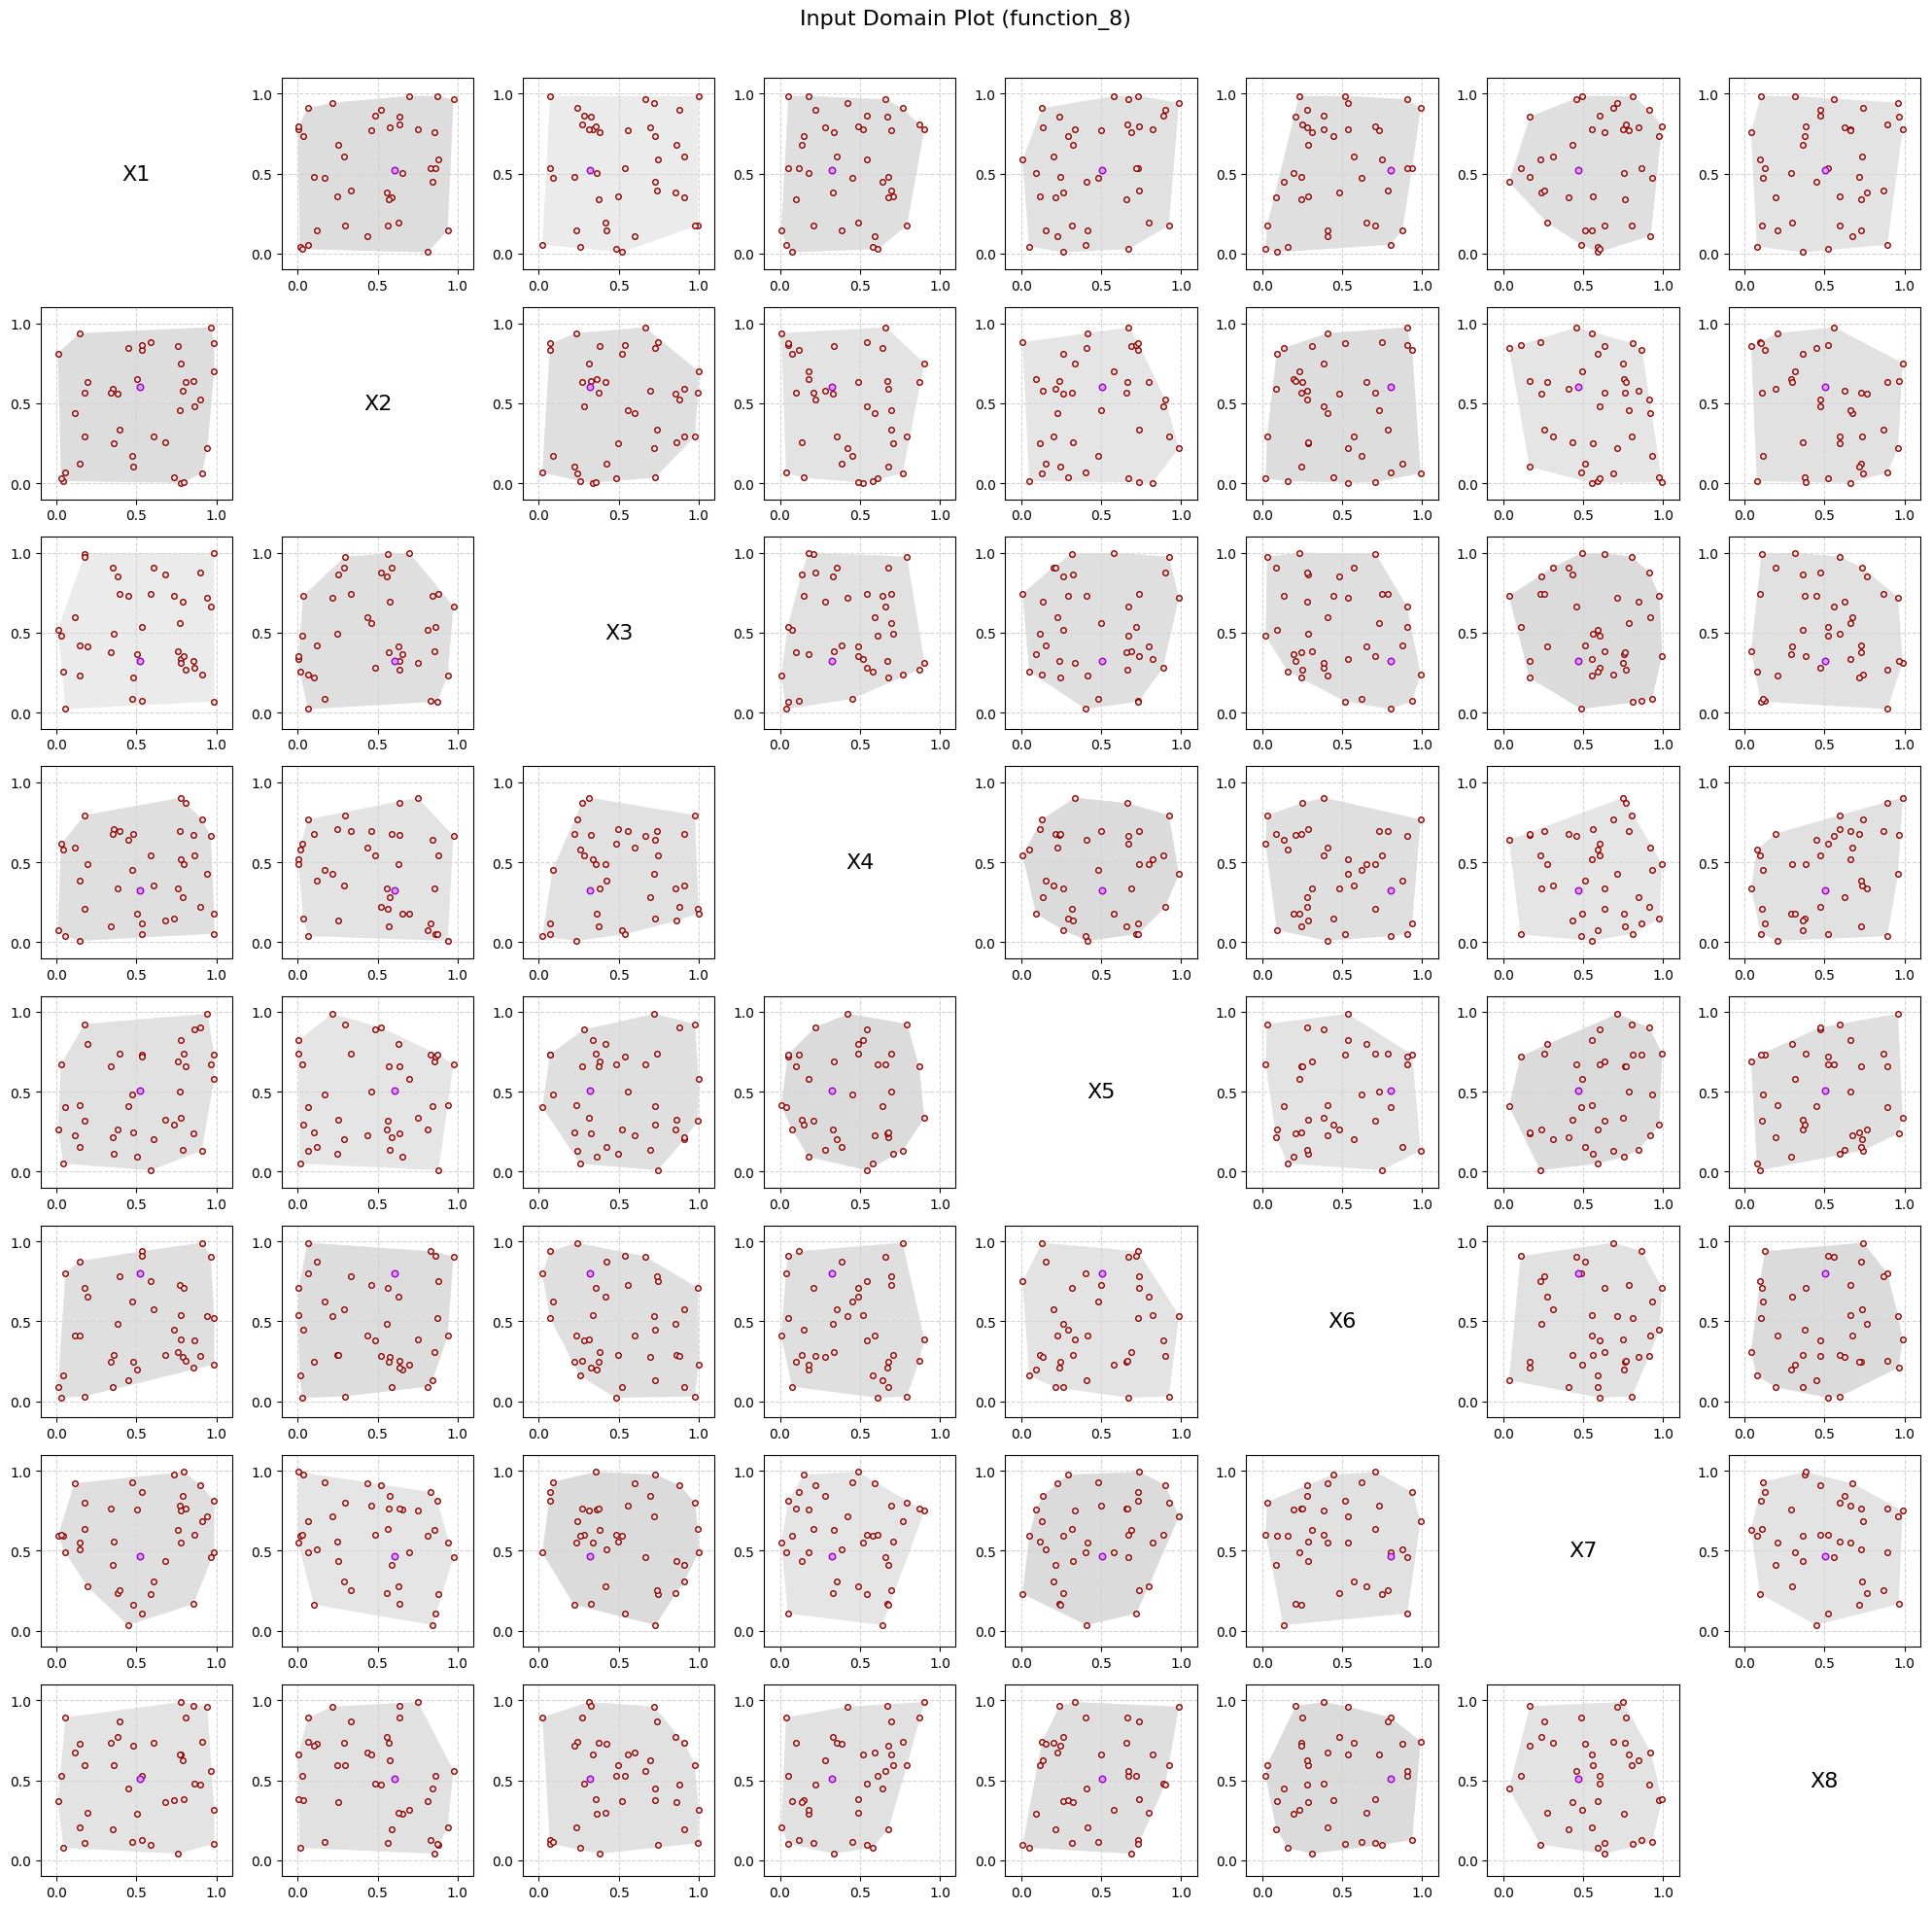

In [196]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points,hull = hull, next_point = best_point_dict)

#### write next point to csv

In [197]:
data_loading.append_results(results_dir, data_folder_name, best_point_dict)

In [198]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.519990-0.603534-0.321304-0.323099-0.508552-0.801879-0.469138-0.506736
